# Phase 2: Forward Neural Network Primitives

Small examples for the completed forward-only neural network features.

In [1]:
from IPython.display import Image
from babygrad.nn import CCE, MSE, Linear, ReLU, Sequential, Softmax
from babygrad.plot import histogram
from babygrad.tensor import Tensor

## Linear layer

The linear layer maps each input row from `input_size` values to `output_size` values.

In [2]:
layer = Linear(input_size=2, output_size=3)
layer.weights = Tensor([1, 2, 3, 4, 5, 6], shape=(2, 3))
layer.bias = Tensor([10, 20, 30], shape=(1, 3))

inputs = Tensor([1, 2, 3, 4], shape=(2, 2))
outputs = layer.forward(inputs)

outputs

2 rows x 3 cols
[
  [19  32  45]
  [29  46  63]
]

## ReLU activation

ReLU preserves shape and clamps negative values to zero.

In [3]:
activation = ReLU()
activation.forward(Tensor([-2, -1, 0, 3, 4, -5], shape=(2, 3)))

2 rows x 3 cols
[
  [0  0  0]
  [3  4  0]
]

## Softmax activation

Softmax preserves the input shape and normalizes each row into probabilities.

In [4]:
logits = Tensor([0, 0, 0, 2, 2, 2], shape=(2, 3))
probabilities = Softmax().forward(logits)
row_sums = probabilities.sum(axis=1)

{
    "probabilities": probabilities,
    "row_sums": row_sums,
}

{'probabilities': 2 rows x 3 cols
 [
   [0.3333  0.3333  0.3333]
   [0.3333  0.3333  0.3333]
 ],
 'row_sums': 2 rows x 1 cols
 [
   [1.0]
   [1.0]
 ]}

## Sequential model

Sequential runs each layer in order and can optionally collect a trace of intermediate tensors.

In [5]:
hidden = Linear(input_size=2, output_size=2)
hidden.weights = Tensor([1, -2, 3, -4], shape=(2, 2))
hidden.bias = Tensor([0, 0], shape=(1, 2))

output = Linear(input_size=2, output_size=1)
output.weights = Tensor([2, 5], shape=(2, 1))
output.bias = Tensor([1], shape=(1, 1))

model = Sequential([hidden, ReLU(), output])
prediction, trace = model.forward(Tensor([1, 1, 2, 1], shape=(2, 2)), plot=True)

{
    "prediction": prediction,
    "trace": trace,
}

{'prediction': 2 rows x 1 cols
 [
   [ 9]
   [11]
 ],
 'trace': {'Linear_0': Trace(data=[4, -6, 5, -8], shape=(2, 2)),
  'ReLU_1': Trace(data=[4, 0, 5, 0], shape=(2, 2)),
  'Linear_2': Trace(data=[9, 11], shape=(2, 1))}}

## Trace plotting

The collected trace can be plotted to inspect the distribution of values after each layer.

Saved histogram to /tmp/babygrad_phase2_trace_histogram.png.


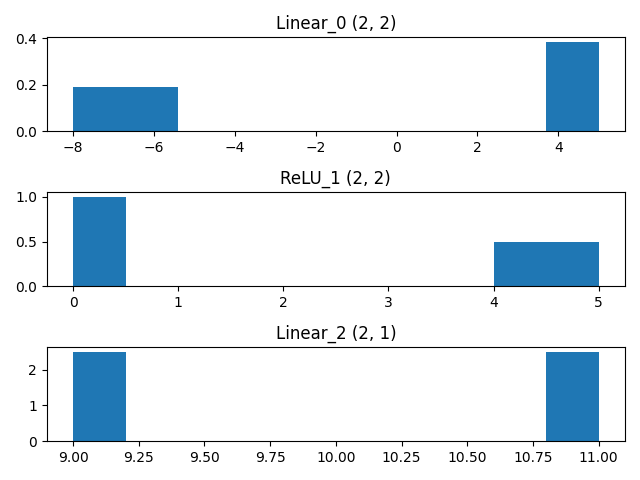

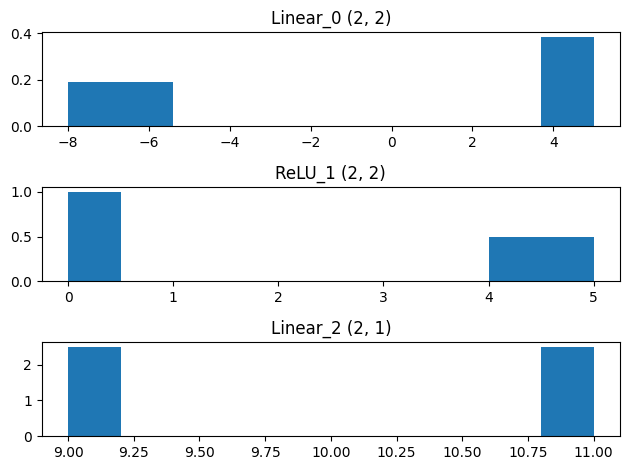

In [6]:
trace_image_path = "/tmp/babygrad_phase2_trace_histogram.png"

histogram(trace, trace_image_path)
Image(filename=trace_image_path)

## Loss functions

The forward loss helpers return a scalar-shaped tensor that can later become the starting point for backprop.

In [7]:
regression_target = Tensor([1, 2, 3, 4], shape=(2, 2))
regression_prediction = Tensor([1, 1, 5, 0], shape=(2, 2))
mse_loss = MSE(regression_target, regression_prediction)

classification_target = Tensor([0, 1, 0, 1, 0, 0], shape=(2, 3))
classification_prediction = Tensor([0.1, 0.8, 0.1, 0.7, 0.2, 0.1], shape=(2, 3))
cce_loss = CCE(classification_target, classification_prediction)

{
    "mse": mse_loss,
    "cross_entropy": cce_loss,
}

{'mse': 1 rows x 1 cols
 [
   [5.25]
 ],
 'cross_entropy': 1 rows x 1 cols
 [
   [0.2899]
 ]}